In [1]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directories
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
sns.set_style('whitegrid')

In [3]:
path = '/Users/kevinbarry/git/IBM_HR_Analytics/WA_Fn-UseC_-HR-Employee-Attrition.csv'

def load_hr_data(path: str) -> pd.DataFrame:
	df = pd.read_csv(path)
	df = df.drop(columns = ['EmployeeCount', 'StandardHours', 'Over18'])
	df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)
	return df

df = load_hr_data(path)

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [5]:
def inspect_data(df: pd.DataFrame) -> None:
	print(f'Shape: {df.shape}')
	print(f'\nAttrition split:\n{df["Attrition_bin"].value_counts(normalize=True).round(3)}')
	nulls = df.isnull().sum()
	nulls = nulls[nulls > 0] 
	print(f'\nNulls: {"None" if len(nulls) == 0 else nulls.to_string()}')
	summary = (
		df.groupby('Department')
		.agg(headcount = ('EmployeeNumber', 'count'),
			avg_income=('MonthlyIncome', 'mean'),
			attrition_rate=('Attrition_bin', 'mean'))
		.round(2).reset_index()
		)
	print(f'\nDept summary:\n{summary.to_string()}')

inspect_data(df)

Shape: (1470, 33)

Attrition split:
Attrition_bin
0    0.839
1    0.161
Name: proportion, dtype: float64

Nulls: None

Dept summary:
               Department  headcount  avg_income  attrition_rate
0         Human Resources         63     6654.51            0.19
1  Research & Development        961     6281.25            0.14
2                   Sales        446     6959.17            0.21


### Dataset: IBM HR Employee Attrition

Shape: (1470, 33)    

Target: Attrition_bin    Class split: ~16% positive

Key numerics: MonthlyIncome, Age, YearsAtCompany, JobLevel, TotalWorkingYears

Dropped constants: EmployeeCount, StandardHours, Over18    Nulls: None

In [26]:
# 2. Summary statistics
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [27]:
# 3. Data types of each column
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [28]:
# 4. Count of missing values per column
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [29]:
# 5. Create a binary target column
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)

In [30]:
# 6 Check class balance
print(df['Attrition_bin'].value_counts(normalize=True).round(3))

Attrition_bin
0    0.839
1    0.161
Name: proportion, dtype: float64


Summary of dataset analysis
- 1470 rows & 35 columns
- The object columns are: Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MartialStatus, 
Over18, OverTime
- The attrition rate is 16.1% - This is imbalanced (5:1 ratio) - will need to stratify later
- No nulls present in the dataset

### Operation 1 - Boolean Filtering

In [31]:
# filter to employees who left
left_df = df[df['Attrition'] == 'Yes']
print(left_df. shape)

(237, 36)


In [32]:
# Filter with a numeric condition 
high_earners = df[df['MonthlyIncome'] > 10000]
print(high_earners.shape)

(281, 36)


In [33]:
# Filter with two conditions - use & not 'and', wrap each in parentheses
left_high = df[(df['Attrition'] == 'Yes') & (df['MonthlyIncome'] > 10000)]
print(left_high.shape)

(25, 36)


In [34]:
# Filter with OR - use | not 'or'
sales_or_hr = df[(df['Department'] == 'Sales') | (df['Department'] == 'Human Resources')]
print(sales_or_hr.shape)

(509, 36)


In [35]:
# select specific columns after filtering
result = df.loc[df['MonthlyIncome'] > 10000, ['Department', 'JobRole', 'MonthlyIncome']]
print(result.head())

                Department                    JobRole  MonthlyIncome
18                   Sales                    Manager          15427
22  Research & Development          Research Director          11994
25  Research & Development                    Manager          19094
28  Research & Development  Healthcare Representative          10248
29                   Sales                    Manager          18947


### Operation 2 - .loc[] for label based selection

In [36]:
# .loc [row_condition, columns_to_select]
# Rows: boolean condition. Columns: list of names
subset = df.loc[df['MonthlyIncome'] > 10000, ['Department', 'JobRole', 'MonthlyIncome']]
print(subset.head())

                Department                    JobRole  MonthlyIncome
18                   Sales                    Manager          15427
22  Research & Development          Research Director          11994
25  Research & Development                    Manager          19094
28  Research & Development  Healthcare Representative          10248
29                   Sales                    Manager          18947


In [37]:
# Select all rows, specific columns
cols_only = df.loc[:, ['Department', 'JobRole', 'MonthlyIncome']]
print(cols_only.head())

               Department                JobRole  MonthlyIncome
0                   Sales        Sales Executive           5993
1  Research & Development     Research Scientist           5130
2  Research & Development  Laboratory Technician           2090
3  Research & Development     Research Scientist           2909
4  Research & Development  Laboratory Technician           3468


In [38]:
# iloc[] uses integer positions instead of labels
first_five = df.iloc[0:5] # first 5 rows, all columns
cell = df.iloc[0,2] # first row, third column (0-indexed)
print(first_five)
print(cell) 

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  StandardHours StockOptionLevel  TotalWorkingYears  \
0  ...       

In [39]:
### Operation 3 - groupby with named aggregation
# named agregation - clean column naming in one step
dept_summary = (
    df.groupby('Department')
    .agg(
        headcount = ('EmployeeNumber', 'count'),
        avg_income = ('MonthlyIncome', 'mean'),
        attrition_rate = ('Attrition_bin', 'mean'),
        avg_age = ('Age', 'mean'),      

    )
    .reset_index()
    .round(2)
)
print(dept_summary)

               Department  headcount  avg_income  attrition_rate  avg_age
0         Human Resources         63     6654.51            0.19    37.81
1  Research & Development        961     6281.25            0.14    37.04
2                   Sales        446     6959.17            0.21    36.54


- Sales has the highest attrition rate with R&D having the lowest
- .reset_index required otherwise the 'Department' column would have become the index and could not be used for charts/graphs

### Pivot
- Operation 1 - pd.pivot_table()

In [40]:
# Cross-tablulate: avg MonthlyIncome by Department AND Attrition
pivot = pd.pivot_table(
    df,
    values='MonthlyIncome',
    index = 'Department',
    columns = 'Attrition',
    aggfunc= 'mean',
    fill_value=0
).round(0)
print(pivot)

Attrition                   No     Yes
Department                            
Human Resources         7346.0  3716.0
Research & Development  6630.0  4108.0
Sales                   7232.0  5908.0


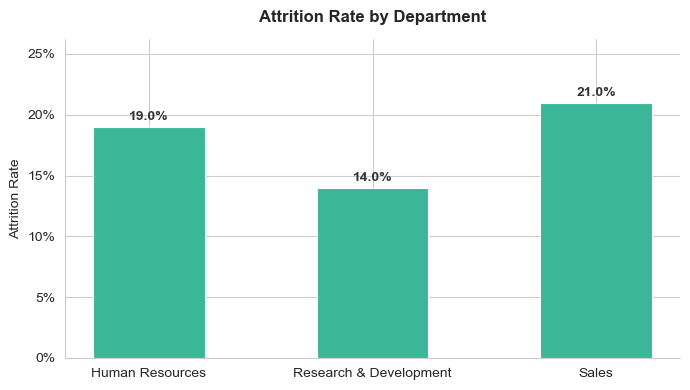

In [41]:
fig, ax = plt.subplots(figsize=(7,4))

bars = ax.bar(
    dept_summary['Department'],
    dept_summary['attrition_rate'],
    color="#39B798",
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

# Value labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.1%}",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#333333'
    )

# Y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, dept_summary['attrition_rate'].max() * 1.25)

# Labels and style
ax.set_title('Attrition Rate by Department', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('')                          # department name is self-evident
ax.set_ylabel('Attrition Rate', fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/attrition_by_department.png', dpi=150)
plt.show()

- Employees who left IBM earned less across all three departments than those who remained with the company. The average monthly income difference ranged from a low of 1,300 in Sales to a high of 3,600 in Human Resources
- As seen in the above chart, the Sales department experienced the greatest attrition followed by HR and then R&D. 

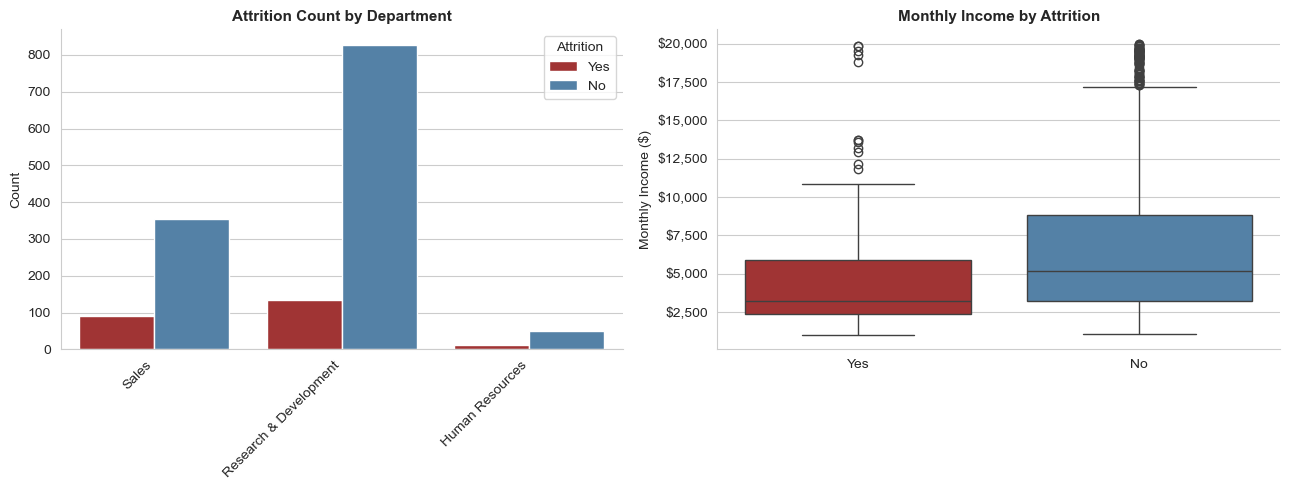

In [42]:
fig, axes = plt.subplots(1,2, figsize=(13,5))

# Left panel: count of Yes/No by department
sns.countplot(
    x='Department',
    hue='Attrition',
    data=df,
    ax=axes[0],
    palette={'Yes': 'firebrick', 'No': 'steelblue'}
)
axes[0].set_title('Attrition Count by Department', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].legend(title='Attrition')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# Right panel: income distribution by Attrition
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df,
    ax=axes[1],
    hue='Attrition',
    palette={'Yes': 'firebrick', 'No': 'steelblue'}
)
axes[1].set_title('Monthly Income by Attrition', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Monthly Income ($)', fontsize=10)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${y:,.0f}')
    )

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/eda_01.png', dpi=150, bbox_inches='tight')
plt.show()

- From the chart above we can see that the attrition in both HR & Sales are much higher in these departments in comparison to R&D
- Also, the red boxplot on the right side chart shows that the majority of employees lost to attrition were on an average salary approximately $2,000 monthly less that the average for those that stayed with the company. 

- Operation 2 - assign w/lambda chain

In [43]:
# add multiple new columns in one call - no temp variables

df = df.assign(
    age_group = lambda x: pd.cut(
        x['Age'],
        bins = [18, 30, 40, 50, 65],
        labels = ['20s', '30s', '40s', '50+']

    ),
    is_manager = lambda x: x['JobRole'].str.contains('Manager').astype(int),
    seniority_score = lambda x: x['YearsAtCompany'] * x['JobLevel'],
)

# Verify the new columns exits
print(df[['Age', 'age_group', 'JobRole', 'is_manager', 'seniority_score']].head(5))
print(df['age_group'].value_counts())


   Age age_group                JobRole  is_manager  seniority_score
0   41       40s        Sales Executive           0               12
1   49       40s     Research Scientist           0               20
2   37       30s  Laboratory Technician           0                0
3   33       30s     Research Scientist           0                8
4   27       20s  Laboratory Technician           0                2
age_group
30s    619
20s    378
40s    322
50+    143
Name: count, dtype: int64


- Operation 3 - pd.cut() detail

In [44]:
# pd.cut() - bin a continuous column into labelled categories
# bins defines the EDGES - so [18,30,40, 50, 65] creates 4 bins: 18-30, 30-40, 40-50, 50-65
# [18,30] = '20s', (30,40) = '30s', (40,50) = '40s', (50,65] = '50+'

age_group = pd.cut(
    df['Age'],
    bins = [18,30,40,50,65],
    labels = ['20s', '30s', '40s', '50+']   

)
# pd.qcut() - bin by quantiles instead of fixed edges
# q=4 creates quantiles: Q1, Q2, Q3, Q4
income_quartile = pd.qcut(df['MonthlyIncome'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

#Difference: cut() = fixed boundaries. qcut() = equal-sized groups


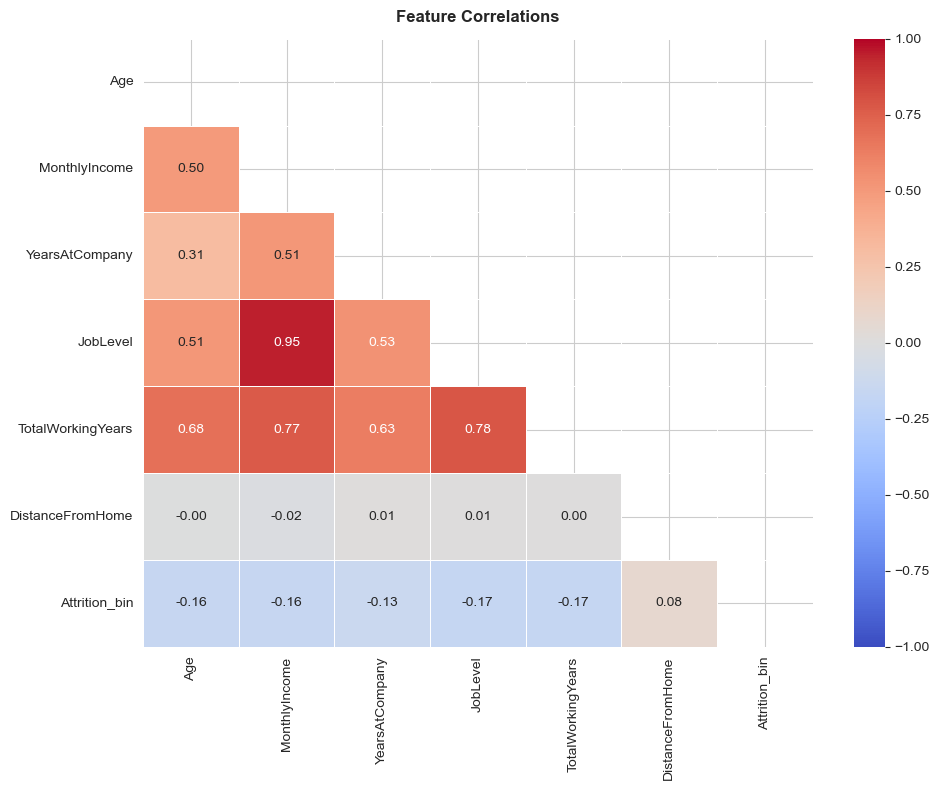

In [45]:
# Correlation heatmap

# Select only numeric columns for correlation
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobLevel',
            'TotalWorkingYears', 'DistanceFromHome', 'Attrition_bin']

# Compute correlation matrix
corr = df[num_cols].corr()

# Build triangle mask - True - hide that cell
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlations', fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


- Based on the heatmap above:
- JobLevel and MonthlyIncome: strong positive correlation (0.95) - seniority drives pay
- TotalWorkingYears and Age: strong positive correlation (0.68) - expected
- TotalWorkingYears also has strong postive correlations with MonthlyIncome, YearsAtCompany & JobLevel
- No single feature predicts attrition, thus a model will be required